### **Autor:** David Roca Tauste

---
---
# **📌ACTIVIDAD 4: APLICAR SVR, ÁRBOLES Y RAMDOMFOREST**
---
---

La entrega se encuentra al final del Notebook. Todo lo que hay delante de la entrega es la preparación de los datos, para luego poder entrenar los modelos.

## Preparación

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.model_selection import GridSearchCV, train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.datasets import make_classification
from sklearn.svm import SVC
from sklearn.calibration import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, SGDRegressor, Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.neighbors import KNeighborsRegressor

from xgboost import XGBRegressor

from joblib import dump, load

In [2]:
ruta = "datos_viviendas.xlsx"
datos = pd.read_excel(ruta)

## Análisis y preprocesamiento de datos

In [3]:
columnas_df = datos.columns.values

for col in columnas_df:
    datos.dropna(subset=[col], inplace=True)

In [4]:
columnas_int = datos.select_dtypes(include=["int64"]).columns
columnas_float = datos.select_dtypes(include=["float64"]).columns
columnas_object = datos.select_dtypes(include=["object"]).columns

In [5]:
# Corregimos los valores 'Si' y 'No' de todas las columnas
pd.set_option('future.no_silent_downcasting', False)

for col in columnas_object:
    datos[col] = datos[col].replace(['si', 'sí', 'Si', 'Sí', 'SI'], 1)
    datos[col] = datos[col].replace(['no', 'No', 'NO'], 0)
    datos[col] = datos[col].astype(datos[col].dtype)

C:\Users\davil\AppData\Local\Temp\ipykernel_10928\3572922239.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  datos[col] = datos[col].replace(['no', 'No', 'NO'], 0)


In [6]:
# Transformamos todos los 'puntos' de las columnas a 'comas' para que sean de tipo float en lugar de object
columnas_deberian_ser_float = ['ricmirber_longitud', 'josrosrod_lat']

for col in columnas_deberian_ser_float:
    datos[col] = datos[col].astype(str).str.replace('.', ',')
    datos[col] = datos[col].str.replace(',', '.').astype(float)

    # Verificamos que el tipo de la columna ha cambiado de object a float
    print(f"Tipo de la columna '{col}': {datos[col].dtype}")

Tipo de la columna 'ricmirber_longitud': float64
Tipo de la columna 'josrosrod_lat': float64


In [7]:
# Corregimos los valores de la columna 'iluminacion'
datos['alvbelnav_iluminacion'] = datos['alvbelnav_iluminacion'].replace(['alta', 'alto', 'Alto'], 'Alta')
datos['alvbelnav_iluminacion'] = datos['alvbelnav_iluminacion'].replace(['media', 'medio', 'Medio'], 'Media')
datos['alvbelnav_iluminacion'] = datos['alvbelnav_iluminacion'].replace(['baja', 'bajo', 'Bajo'], 'Baja')

# Verificamos que se hayan corregido los valores incorrectos
print(datos['alvbelnav_iluminacion'].value_counts())

alvbelnav_iluminacion
Alta     65
Media    53
Baja     21
Name: count, dtype: int64


In [8]:
# Corregimos los valores de la columna 'orientacion'
datos['luctarcom_orientacion'] = datos['luctarcom_orientacion'].replace(['norte'], 'Norte')
datos['luctarcom_orientacion'] = datos['luctarcom_orientacion'].replace(['sur', 'sud', 'Sud', ' Sur'], 'Sur')
datos['luctarcom_orientacion'] = datos['luctarcom_orientacion'].replace(['este'], 'Este')
datos['luctarcom_orientacion'] = datos['luctarcom_orientacion'].replace(['oeste'], 'Oeste')

datos['luctarcom_orientacion'] = datos['luctarcom_orientacion'].replace(['sureste'], 'Sureste')

# Verificamos que se hayan corregido los valores incorrectos
print(datos['luctarcom_orientacion'].value_counts())

luctarcom_orientacion
Sur        39
Este       38
Norte      34
Oeste      17
Sureste     9
Noreste     2
Name: count, dtype: int64


## Selección de características

In [9]:
# Volvemos a obtener las columnas de tipo 'objeto' después de la correción de tipos de las columnas
columnas_object = datos.select_dtypes(include=["object"]).columns

# Codificación de variables
le = LabelEncoder()

for columna in columnas_object:
    print(columna)
    datos[columna] = le.fit_transform(datos[columna])

josrosrod_origen
jorosrod_municipio
alvbelnav_iluminacion
luctarcom_orientacion


In [10]:
valor_objetivo = "josrosrod_precio"

correlaciones = datos.corr()
correlaciones_objetivo = correlaciones[valor_objetivo].drop(valor_objetivo)
mejores_correlaciones = correlaciones_objetivo.abs().sort_values(ascending=False)

print(mejores_correlaciones)

rafmaralf_baños              0.796238
robripcon_habitaciones       0.466557
rauramesc_airecentral        0.219265
alvbelnav_iluminacion        0.175123
josrosrod_dia                0.166240
alegarsal_terraza            0.146424
davsoreng_duplex             0.140811
guifue_parking               0.131303
jorosrod_municipio           0.117791
davroctau_planta             0.108001
josrosrod_lat                0.082342
elilopper_distanciaCentro    0.079379
josrosrod_mes                0.075330
josrosrod_año                0.055204
josrosrod_origen             0.052629
juamarxxx_trastero           0.050703
samartlop_superficie         0.029032
ricmirber_longitud           0.025879
luctarcom_orientacion        0.019661
omapasvac_ascensor           0.015667
Name: josrosrod_precio, dtype: float64


In [11]:
columnas_relevantes_target = list(mejores_correlaciones.head(14).index.values)
datos_relevantes = datos[[valor_objetivo] + columnas_relevantes_target]

datos_relevantes.drop('robripcon_habitaciones', axis=1)

,josrosrod_precio,rafmaralf_baños,rauramesc_airecentral,alvbelnav_iluminacion,josrosrod_dia,alegarsal_terraza,davsoreng_duplex,guifue_parking,jorosrod_municipio,davroctau_planta,josrosrod_lat,elilopper_distanciaCentro,josrosrod_mes,josrosrod_año
0,140000,1,1,0,16,1,0,0,3,1,39.418000,6.0,2,2025
1,85000,1,1,0,16,0,0,0,3,1,39.417000,7.0,2,2025
2,225000,2,1,0,16,2,0,0,3,1,39.414900,6.0,2,2025
3,129999,1,0,0,16,0,0,0,3,2,39.414500,6.0,2,2025
4,145000,1,1,1,16,1,0,0,3,1,39.413300,6.0,2,2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135,190000,1,0,2,20,1,0,0,19,0,39.440198,7.6,2,2025
136,185000,1,0,2,5,1,0,0,19,0,39.440198,7.6,2,2025
137,180000,1,0,1,6,0,0,0,19,2,39.440198,7.6,2,2025
138,130000,1,0,2,20,1,0,0,19,4,39.440198,7.6,2,2025


## Entrenamiento de modelos

In [12]:
# Separar datos en entrenamiento y test
X = datos_relevantes.drop(columns=[valor_objetivo])
y = datos_relevantes[valor_objetivo]

semilla = 546
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=semilla)

scaler = StandardScaler()
X_train[columnas_relevantes_target] = scaler.fit_transform(X_train[columnas_relevantes_target])
X_test[columnas_relevantes_target] = scaler.transform(X_test[columnas_relevantes_target])

## ENTREGA 8: Muestra código y capturas de ejecución de configuración y medición de desempeño con gráficos de:
### a) Un regresor con SVM.
### b) Un regresor basado en árboles de decisión.
### c) Un regresor basado en RandomForestRegressor o e GradientBoostingRegressor.

En alguno de ellos muestra importancia o influencia de cada característica usada.

In [13]:
# a) SVM
modelo_svm = SVR()
modelo_svm.fit(X_train, y_train)
y_pred_svm = modelo_svm.predict(X_test)

In [19]:
# b) Decision Tree Regressor
modelo_arbol = DecisionTreeRegressor(random_state=semilla)
modelo_arbol.fit(X_train, y_train)
y_pred_arbol = modelo_arbol.predict(X_test)

In [20]:
# c) Random Forest Regressor
modelo_rf = RandomForestRegressor(n_estimators=100, random_state=semilla)
modelo_rf.fit(X_train, y_train)
y_pred_rf = modelo_rf.predict(X_test)


=== SVM ===
MSE: 125376001579.44702
R2: -0.15177111003835675

=== Árbol de decisión ===
MSE: 90985535714.28572
R2: 0.1641581311661765

=== Random Forest ===
MSE: 48866463553.36119
R2: 0.5510864897470918


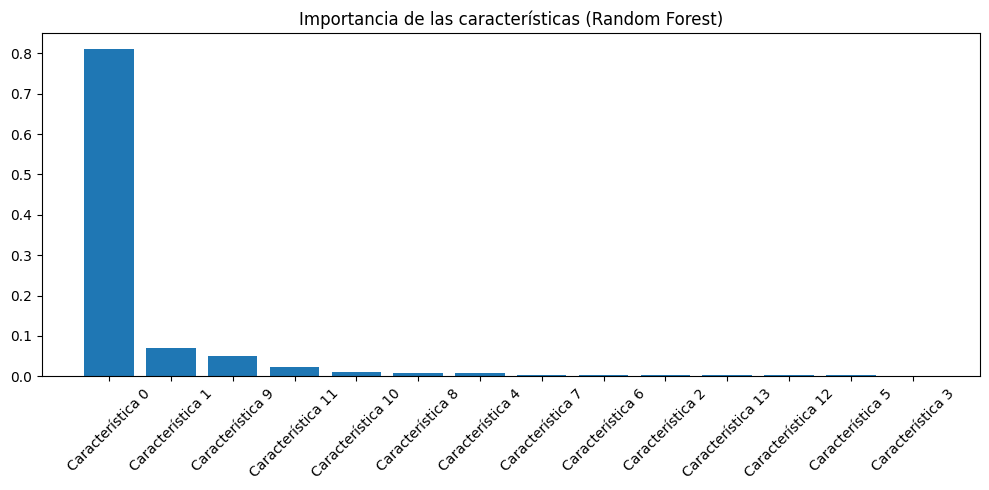

In [26]:
def imprimir_metricas(nombre, y_true, y_pred):
    print(f"\n=== {nombre} ===")
    print("MSE:", mean_squared_error(y_true, y_pred))
    print("R2:", r2_score(y_true, y_pred))

# Métricas
imprimir_metricas("SVM", y_test, y_pred_svm)
imprimir_metricas("Árbol de decisión", y_test, y_pred_arbol)
imprimir_metricas("Random Forest", y_test, y_pred_rf)

# Importancia de características (para Random Forest)
importancias = modelo_rf.feature_importances_
indices = np.argsort(importancias)[::-1]
nombres_caracteristicas = [f"Característica {i}" for i in range(X.shape[1])]

plt.figure(figsize=(10, 5))
plt.title("Importancia de las características (Random Forest)")
plt.bar(range(X.shape[1]), importancias[indices], align="center")
plt.xticks(range(X.shape[1]), [nombres_caracteristicas[i] for i in indices], rotation=45)
plt.tight_layout()
plt.show()